In [1]:
import pandas as pd

In [2]:
# Read a dataset with missing values (download zipped dataset from here)
nfl_data = pd.read_csv('NFL Play by Play 2009-2016 (v3).csv', dtype='unicode')
nfl_data.head()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600,0,TEN,...,NaN,0.4856749860969135,0.5143250139030865,0.5464328397122977,0.4535671602877023,0.4856749860969135,0.060757853615384216,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1,14:53,15,3593,7,PIT,...,1.1460758055888012,0.5464328397122977,0.4535671602877023,0.5510878171614882,0.44891218283851175,0.5464328397122977,0.004654977449190523,-0.03224398696619424,0.03689896441538476,2009
2,2009-09-10,2009091000,1,1,2,14:16,15,3556,37,PIT,...,NaN,0.5510878171614882,0.44891218283851175,0.5107930906986009,0.4892069093013991,0.5510878171614882,-0.04029472646288734,NaN,NaN,2009
3,2009-09-10,2009091000,1,1,3,13:35,14,3515,41,PIT,...,-5.031424582246548,0.5107930906986009,0.4892069093013991,0.4612171140114365,0.5387828859885635,0.5107930906986009,-0.0495759766871644,0.10666255529932689,-0.1562385319864913,2009
4,2009-09-10,2009091000,1,1,4,13:27,14,3507,8,PIT,...,NaN,0.4612171140114365,0.5387828859885635,0.5589294012224711,0.44107059877752886,0.4612171140114365,0.09771228721103464,NaN,NaN,2009


In [3]:
nfl_data.isnull().head()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False


In [4]:
# get the number of missing data points per column; sum True values
missing_values_count = nfl_data.isnull().sum()

# look at the # of missing points in the first ten columns
missing_values_count[0:10]

Date                0
GameID              0
Drive               0
qtr                 0
down            54218
time              188
TimeUnder           0
TimeSecs          188
PlayTimeDiff      374
SideofField       450
dtype: int64

In [5]:
# remove all the rows that contain a missing value
nfl_data.dropna()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season


In [6]:
# remove all columns with at least one missing value
columns_cleaned = nfl_data.dropna(axis=1)
columns_cleaned.head()

,Date,GameID,Drive,qtr,TimeUnder,ydstogo,ydsnet,PlayAttempted,Yards.Gained,sp,...,AwayTeam,Timeout_Indicator,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,HomeTimeouts_Remaining_Post,AwayTimeouts_Remaining_Post,ExPoint_Prob,TwoPoint_Prob,Season
0,2009-09-10,2009091000,1,1,15,0,0,1,39,0,...,TEN,0,3,3,3,3,3,0,0,2009
1,2009-09-10,2009091000,1,1,15,10,5,1,5,0,...,TEN,0,3,3,3,3,3,0,0,2009
2,2009-09-10,2009091000,1,1,15,5,2,1,-3,0,...,TEN,0,3,3,3,3,3,0,0,2009
3,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0,0,2009
4,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0,0,2009


In [7]:
# just how much data did we lose?
print("Columns in original dataset: %d" % nfl_data.shape[1])
print("Columns with na's dropped: %d" % columns_cleaned.shape[1])

Columns in original dataset: 102
Columns with na's dropped: 37


In [8]:
# replace all NA's with 0
nfl_data = nfl_data.fillna(0)

In [9]:
# replace all NA's the value that comes directly after it in the same column, then replace all the remaining na's with 0
nfl_data = nfl_data.bfill(axis=0).fillna(0)

In [10]:
# Using Sklearn’s simple imputer
from sklearn.impute import SimpleImputer
import numpy as np
my_imputer = SimpleImputer(missing_values=np.NaN, strategy='mean')
nfl_data[['yacWPA']] = my_imputer.fit_transform(nfl_data[['yacWPA']])

In [11]:
nfl_data.head()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,0,15:00,15,3600,0,TEN,...,0,0.4856749860969135,0.5143250139030865,0.5464328397122977,0.4535671602877023,0.4856749860969135,0.060757853615384216,0,0.000000,2009
1,2009-09-10,2009091000,1,1,1,14:53,15,3593,7,PIT,...,1.1460758055888012,0.5464328397122977,0.4535671602877023,0.5510878171614882,0.44891218283851175,0.5464328397122977,0.004654977449190523,-0.03224398696619424,0.036899,2009
2,2009-09-10,2009091000,1,1,2,14:16,15,3556,37,PIT,...,0,0.5510878171614882,0.44891218283851175,0.5107930906986009,0.4892069093013991,0.5510878171614882,-0.04029472646288734,0,0.000000,2009
3,2009-09-10,2009091000,1,1,3,13:35,14,3515,41,PIT,...,-5.031424582246548,0.5107930906986009,0.4892069093013991,0.4612171140114365,0.5387828859885635,0.5107930906986009,-0.0495759766871644,0.10666255529932689,-0.156239,2009
4,2009-09-10,2009091000,1,1,4,13:27,14,3507,8,PIT,...,0,0.4612171140114365,0.5387828859885635,0.5589294012224711,0.44107059877752886,0.4612171140114365,0.09771228721103464,0,0.000000,2009


#### Removing outliers

(3.0, 44.0)

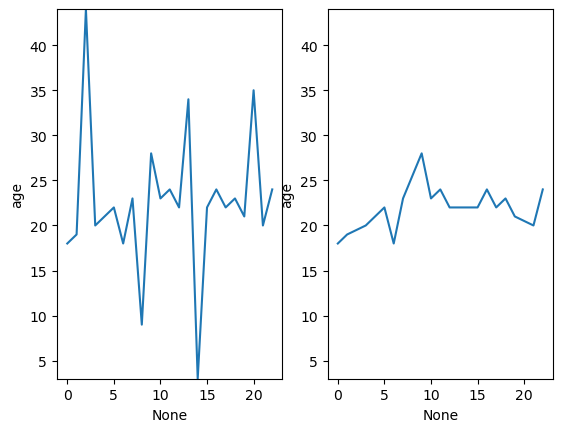

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
df2 = pd.DataFrame({'age': [18, 19, 44, 20, 21, 22, 18, 23, 9, 28, 23, 24, 22, 34, 3, 22, 24, 22, 23, 21, 35, 20, 24]})
plt.subplot(1,2,1)
sns.lineplot(data=df2, y=df2['age'], x=df2.index)
plt.ylim([df2['age'].min(), df2['age'].max()])
Q1 = df2['age'].quantile(0.25)
Q3 = df2['age'].quantile(0.75)
IQR = Q3-Q1
maximum = Q3 + 1.5*IQR
minimum = Q1 - 1.5*IQR
df3 = df2[ (df2['age'] > minimum) & (df2['age'] < maximum) ]
plt.subplot(1,2,2)
sns.lineplot(data=df3, y=df3['age'], x=df3.index)
plt.ylim([df2['age'].min(), df2['age'].max()])

(3.0, 44.0)

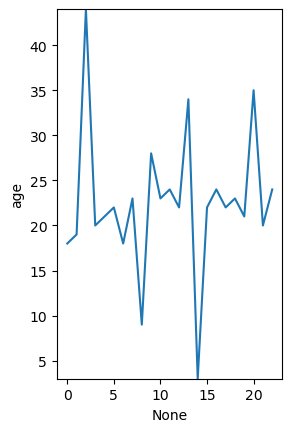

In [13]:
mean = df2['age'].mean()
std = df2['age'].std()
maximum = mean + 3*std
minimum = mean - 3*std
df4 = df2[ (df2['age'] > minimum) & (df2['age'] < maximum) ]
plt.subplot(1,2,2)
sns.lineplot(data=df4, y=df4['age'], x=df4.index)
plt.ylim([df2['age'].min(), df2['age'].max()])

(3.0, 44.0)

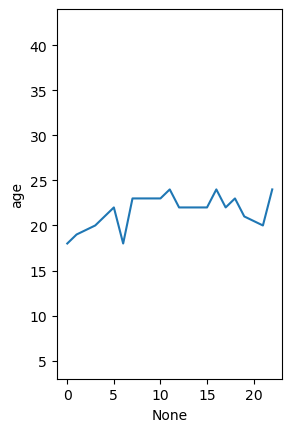

In [14]:
import scipy as sp
median = df2['age'].median()
mad = sp.stats.median_abs_deviation(df2['age'])
maximum = median + 3*mad
minimum = median - 3*mad
df4 = df2[ (df2['age'] > minimum) & (df2['age'] < maximum) ]
plt.subplot(1,2,2)
sns.lineplot(data=df4, y=df4['age'], x=df4.index)
plt.ylim([df2['age'].min(), df2['age'].max()])

In [15]:
# Mean/std vs Median/mad
df2 = pd.DataFrame({'age': [2,3,5,6,9,1000]})
print(df2.age.mean(), df2.age.std(), df2.age.median(), sp.stats.median_abs_deviation(df2['age'])) 

170.83333333333334 406.21443434061604 5.5 3.0


#### Encoding categorical data

In [16]:
import category_encoders as ce

df=pd.DataFrame({'Degree':['High school','Masters','Diploma','Bachelors','Bachelors','Masters','Phd','High school','High school']})
#Original data
df

,Degree
0,High school
1,Masters
2,Diploma
3,Bachelors
4,Bachelors
5,Masters
6,Phd
7,High school
8,High school


In [17]:
# create object of Ordinal encoding
ordinal_encoder= ce.OrdinalEncoder(cols=['Degree'],
                           mapping=[{'col':'Degree', 'mapping':{'None':0,'High school':1,'Diploma':2,'Bachelors':3,'Masters':4,'Phd':5}}])

#fit and transform data
df['Ordinal'] = ordinal_encoder.fit_transform(df)
df

,Degree,Ordinal
0,High school,1
1,Masters,4
2,Diploma,2
3,Bachelors,3
4,Bachelors,3
5,Masters,4
6,Phd,5
7,High school,1
8,High school,1


In [18]:
# Create object for One-hot encoding
onehot_encoder=ce.OneHotEncoder(cols=['Degree'], use_cat_names=True)
#fit and transform data
df_onehot = onehot_encoder.fit_transform(df)
df_onehot

,Degree_High school,Degree_Masters,Degree_Diploma,Degree_Bachelors,Degree_Phd,Ordinal
0,1,0,0,0,0,1
1,0,1,0,0,0,4
2,0,0,1,0,0,2
3,0,0,0,1,0,3
4,0,0,0,1,0,3
5,0,1,0,0,0,4
6,0,0,0,0,1,5
7,1,0,0,0,0,1
8,1,0,0,0,0,1


In [19]:
df_dummy = pd.get_dummies(df, drop_first=True)
df_dummy

,Ordinal,Degree_Diploma,Degree_High school,Degree_Masters,Degree_Phd
0,1,False,True,False,False
1,4,False,False,True,False
2,2,True,False,False,False
3,3,False,False,False,False
4,3,False,False,False,False
5,4,False,False,True,False
6,5,False,False,False,True
7,1,False,True,False,False
8,1,False,True,False,False


2001-10-30 16:51:53
2001-11-10 17:11:13
2001-01-01 07:21:13
2001-06-05 13:44:13
2001-05-04 23:59:53


<Axes: xlabel='hour_sin', ylabel='hour_cos'>

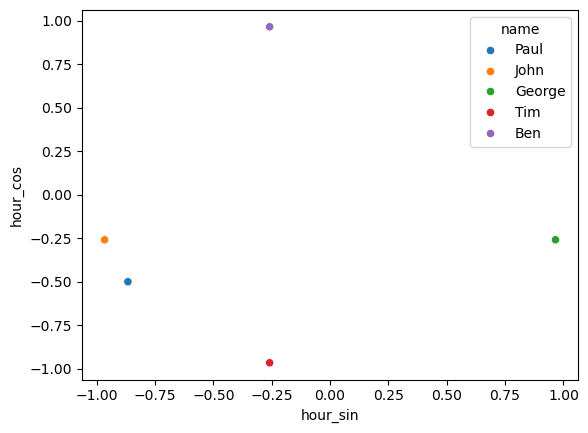

In [20]:
from datetime import datetime
from math import sin, cos, pi

days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

def sin_cos(n):
    theta = 2 * pi * n
    return (sin(theta), cos(theta))

def get_cycles(d):
    '''
    Get the cyclic properties of a datetime,
    represented as points on the unit circle.
    Arguments
    ---------
    d : datetime object
    Returns
    -------
    dictionary of sine and cosine tuples
    '''
    month = d.month - 1
    day = d.day - 1
    return {
        'month': sin_cos(month / 12),
        'day': sin_cos(day / days_in_month[month]),
        'weekday': sin_cos(d.weekday() / 7),
        'hour': sin_cos(d.hour / 23),
        'minute': sin_cos(d.minute / 60),
        'second': sin_cos(d.second / 60)
    }

def get_cycle(d, x):
    '''
    Get the cyclic properties of a datetime,
    represented as points on the unit circle.
    Arguments
    ---------
    d : datetime object
    Returns
    -------
    dictionary of sine and cosine tuples
    '''
    print(d)
    month = d.month - 1
    day = d.day - 1
    if x == 'month':
        return sin_cos(month / 12)
    elif x == 'day':
        return sin_cos(day / days_in_month[month])
    elif x == 'weekday':
        return sin_cos(d.weekday() / 7)
    elif x == 'hour':
        return sin_cos(d.hour / 24)
    elif x == 'minute':
        return sin_cos(d.minute / 60)
    elif x == 'second':
        return sin_cos(d.second / 60)

#get_cycle(datetime(2018, 6, 3, 16, 51, 53), 'day')
df = pd.DataFrame({'name':['Paul', 'John', 'George', 'Tim', 'Ben'], 'birthdate': ['30-10-2001 16:51:53', '10-11-2001 17:11:13', '01-01-2001 07:21:13', '05-06-2001 13:44:13', '04-05-2001 23:59:53']})
df['hour'] = df['birthdate'].map(lambda date_time_str: get_cycle(datetime.strptime(date_time_str, '%d-%m-%Y %H:%M:%S'), 'hour'))
df[['hour_sin', 'hour_cos']] = pd.DataFrame(df['hour'].tolist())
#print(df)
sns.scatterplot(data=df, x=df['hour_sin'], y=df['hour_cos'], hue='name')

#### Scaling data

In [21]:
from sklearn.preprocessing import MinMaxScaler
df = pd.DataFrame({'A': [4, 3, 7], 'B': [13, 2, 8] })

# train the scaler (find min and max)
scaler = MinMaxScaler(feature_range=(0, 1)).fit(df)
# scale the dataset
minMaxRescaledX = scaler.transform(df)
print(minMaxRescaledX)

[[0.25       1.        ]
 [0.         0.        ]
 [1.         0.54545455]]


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df)
# standardize the dataset
standardRescaledX = scaler.transform(df)
print(standardRescaledX)

[[-0.39223227  1.18599891]
 [-0.98058068 -1.26012384]
 [ 1.37281295  0.07412493]]


In [23]:
from sklearn.preprocessing import RobustScaler
# train the standardizer (find median, quantiles)
rscaler = RobustScaler().fit(df)
# standardize the dataset
robustRescaledX = rscaler.transform(df)
print(robustRescaledX)

[[ 0.          0.90909091]
 [-0.5        -1.09090909]
 [ 1.5         0.        ]]


In [24]:
from sklearn.preprocessing import Binarizer
binarizer = Binarizer(threshold=4.0).fit(df)
# binarize the dataset
binaryX = binarizer.transform(df)
print(binaryX)

[[0 1]
 [0 0]
 [1 1]]


#### Unskewing transformations

In [25]:
house_df = pd.read_csv('house_prices_train.csv')
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


1.8828757597682129

<Figure size 640x480 with 0 Axes>

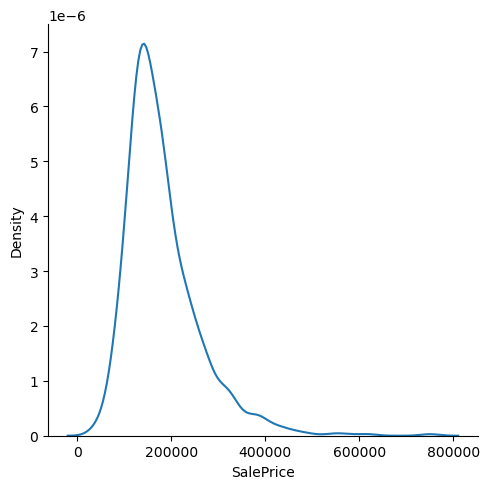

In [26]:
plt.figure()
sns.displot(data=house_df, x='SalePrice', kind='kde')
house_df['SalePrice'].skew()

0.9431527373310963

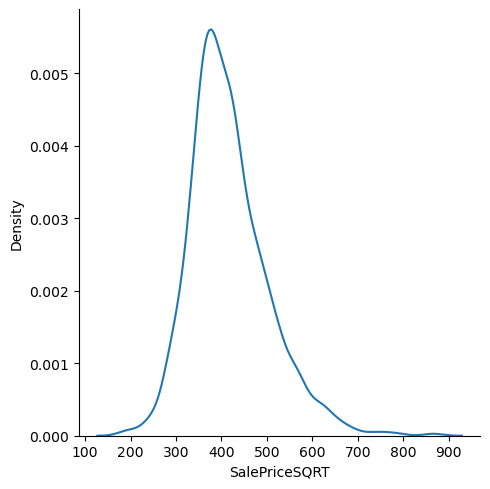

In [27]:
# SQRT transformation
house_df['SalePriceSQRT'] = np.sqrt(house_df['SalePrice'])
sns.displot(data=house_df, x='SalePriceSQRT', kind='kde')
house_df['SalePriceSQRT'].skew()

0.12133506220520406

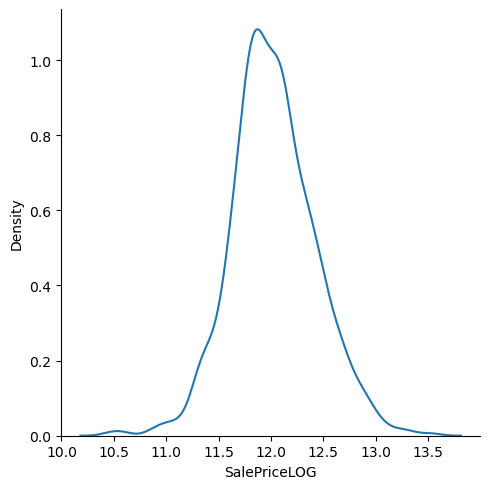

In [28]:
# LOG transformation
house_df['SalePriceLOG'] = np.log(house_df['SalePrice'])
sns.displot(data=house_df, x='SalePriceLOG', kind='kde')
house_df['SalePriceLOG'].skew()

-0.008652893640830073

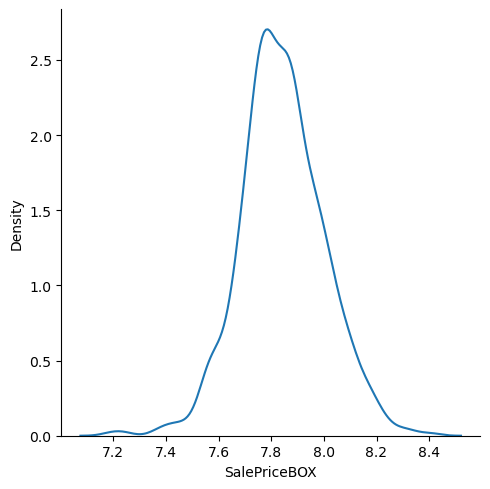

In [29]:
# BOXCOX transformation
house_df['SalePriceBOX'], lambda_ = sp.stats.boxcox(house_df['SalePrice'])
sns.displot(data=house_df, x='SalePriceBOX', kind='kde')
house_df['SalePriceBOX'].skew()

-0.008653730000621727

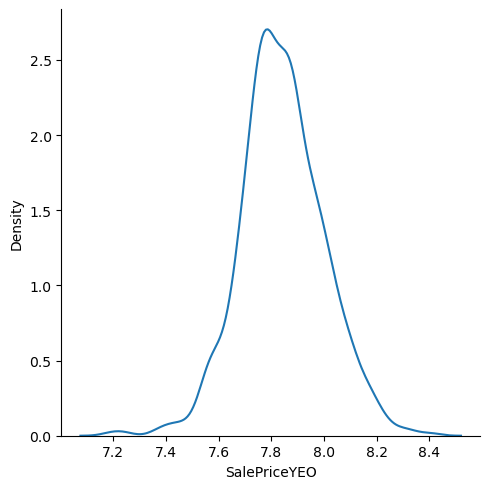

In [30]:
# Yeo Johnson transformation
house_df['SalePriceYEO'], lambda_ = sp.stats.yeojohnson(house_df['SalePrice'])
sns.displot(data=house_df, x='SalePriceYEO', kind='kde')
house_df['SalePriceYEO'].skew()

#### Resampling data

In [31]:
from pandas import read_csv
from datetime import datetime

shampoo_df = read_csv('shampoo.csv')
print(shampoo_df.head())

  Month  Sales
0  1-01  266.0
1  1-02  145.9
2  1-03  183.1
3  1-04  119.3
4  1-05  180.3


In [32]:
shampoo_df['Month'] = shampoo_df['Month'].map(lambda m: datetime.strptime('200'+m, '%Y-%m'))
shampoo_df = shampoo_df.set_index('Month')
print(shampoo_df.head())

            Sales
Month            
2001-01-01  266.0
2001-02-01  145.9
2001-03-01  183.1
2001-04-01  119.3
2001-05-01  180.3


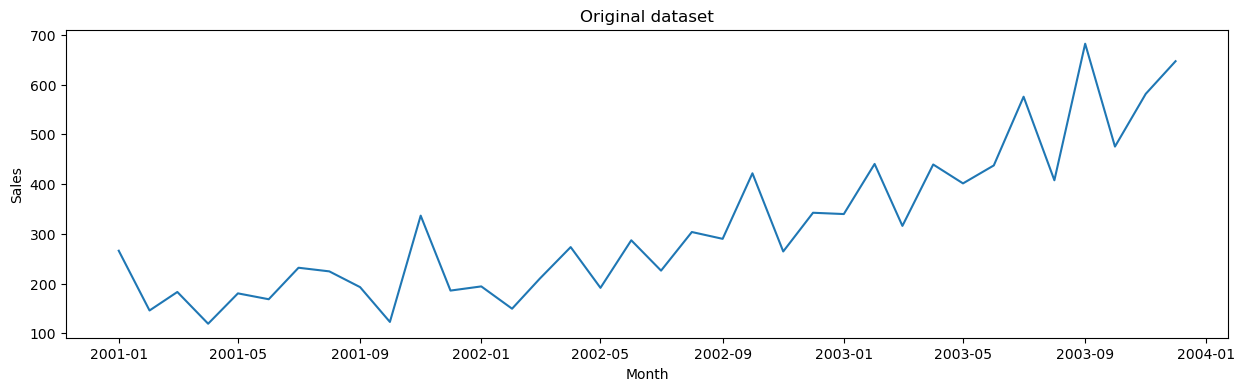

In [33]:
plt.figure(1,figsize=(15,4))
sns.lineplot(data=shampoo_df, x=shampoo_df.index, y=shampoo_df.Sales)
plt.title('Original dataset') 
plt.show()

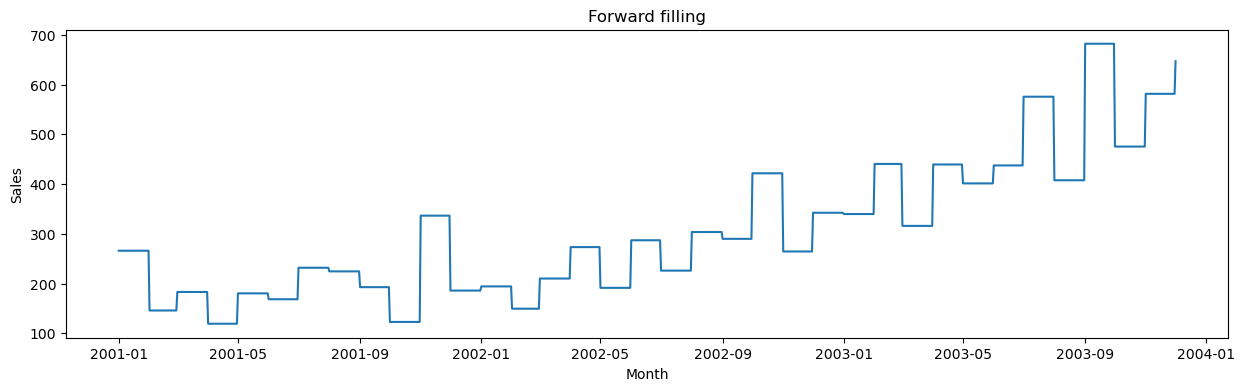

            Sales
Month            
2001-01-01  266.0
2001-01-02  266.0
2001-01-03  266.0
2001-01-04  266.0
2001-01-05  266.0


In [34]:
# UP SAMPLING
# forward fill
daily=shampoo_df.resample('D').ffill()
plt.figure(1,figsize=(15,4))
sns.lineplot(data=daily, x=daily.index, y=daily.Sales)
plt.title('Forward filling') 
plt.show()
print(daily.head())

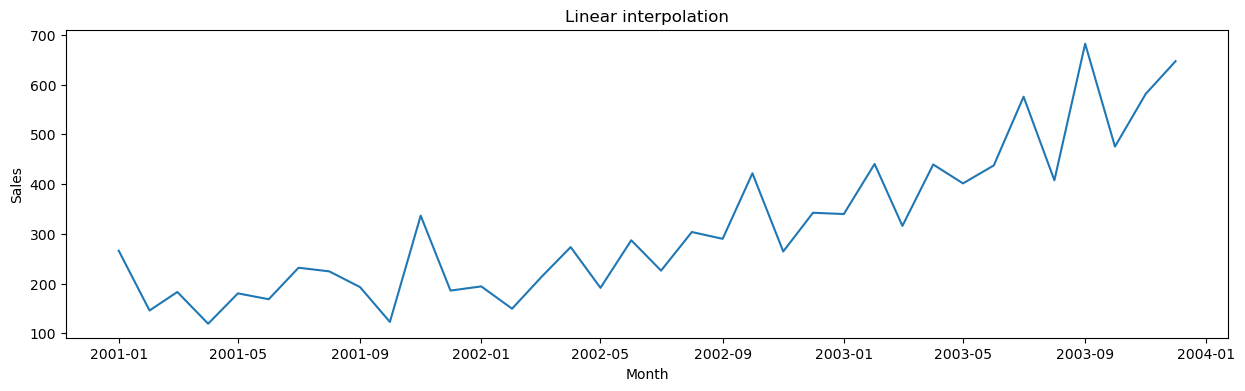

In [35]:
# linear interpolation
daily=shampoo_df.resample('D').interpolate(method='linear')
plt.figure(1,figsize=(15,4))
sns.lineplot(data=daily, x=daily.index, y=daily.Sales)
plt.title('Linear interpolation')
plt.show()

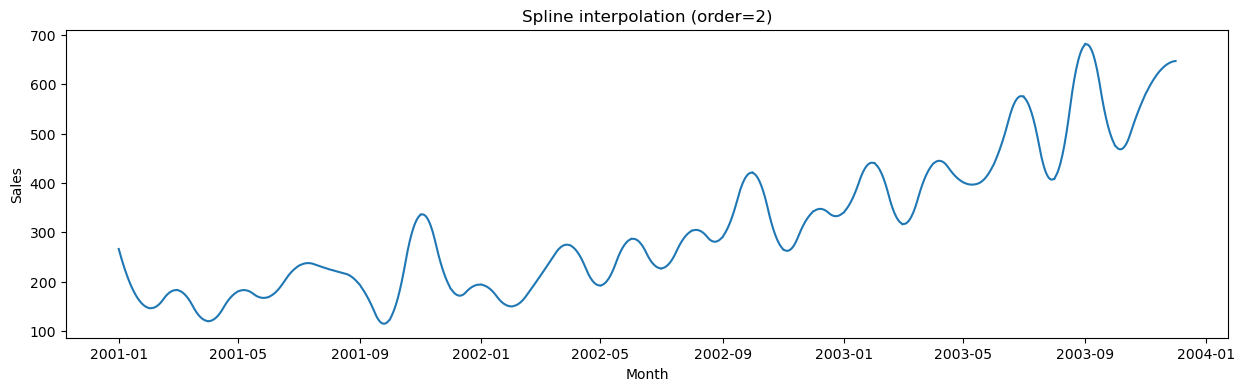

In [36]:
# spline interpolation
daily=shampoo_df.resample('D').interpolate(method='spline', order=2)
plt.figure(1,figsize=(15,4))
sns.lineplot(data=daily, x=daily.index, y=daily.Sales)
plt.title('Spline interpolation (order=2)')
plt.show()

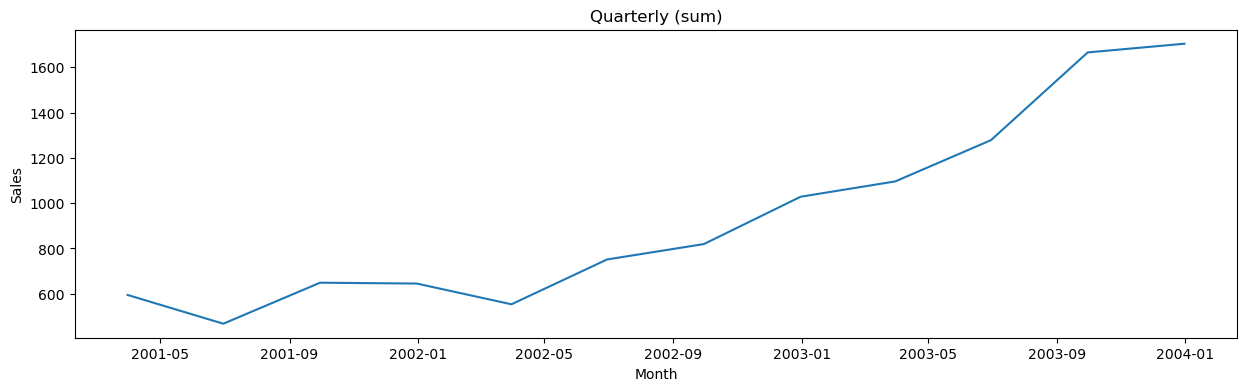

             Sales
Month             
2001-03-31   595.0
2001-06-30   468.1
2001-09-30   649.1
2001-12-31   645.3
2002-03-31   553.9
2002-06-30   751.7
2002-09-30   819.5
2002-12-31  1028.4
2003-03-31  1096.0
2003-06-30  1278.0


In [37]:
# DOWN SAMPLING
# sum
quarterly=shampoo_df.resample('QE').sum()
plt.figure(1,figsize=(15,4))
sns.lineplot(data=quarterly, x=quarterly.index, y=quarterly.Sales)
plt.title('Quarterly (sum)')
plt.show()
print(quarterly.head(10))

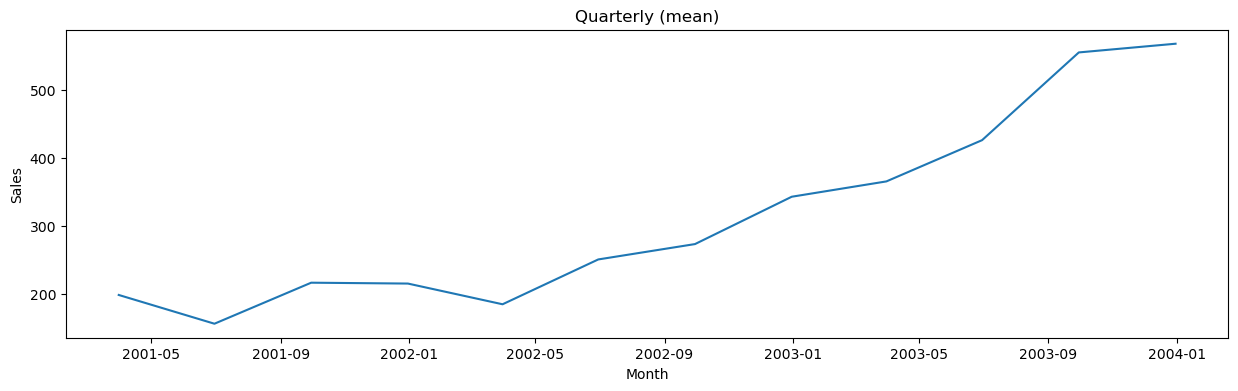

                 Sales
Month                 
2001-03-31  198.333333
2001-06-30  156.033333
2001-09-30  216.366667
2001-12-31  215.100000
2002-03-31  184.633333
2002-06-30  250.566667
2002-09-30  273.166667
2002-12-31  342.800000
2003-03-31  365.333333
2003-06-30  426.000000


In [38]:
# mean
quarterly=shampoo_df.resample('QE').mean()
plt.figure(1,figsize=(15,4))
sns.lineplot(data=quarterly, x=quarterly.index, y=quarterly.Sales)
plt.title('Quarterly (mean)')
plt.show()
print(quarterly.head(10))